# Preprocessing - Immune Cells from Cell Ontology

1. Extraction of immune cell terms based on **hematopoietic cell** descendants
2. Subgraph consturction
3. 

## Imports and global vars

In [1]:
import obonet
import networkx as nx

import sys
sys.path.append("..")

from utils.ontology_model_fns import load_ontology_graph
from utils.ontology_model_fns import make_node2vec_model
from utils.ontology_model_fns import save_model_and_metadata
from utils.ontology_model_fns import get_cl_subtree

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_PATH = "../data/cellxgene_data"
OBO_FOLDER_PATH = "../data/ontologies/obo_files"
SUBGRAPH_ROOT = "CL:0000988"  # "hematopoietic cell"

# Read cell ontology file

In [4]:
cl_graph = obonet.read_obo(f"{OBO_FOLDER_PATH}/cl.obo")  # full Cell Ontology
cl_graph_rev = cl_graph.reverse() # reverse graph

immune_subgraph = get_cl_subtree(cl_graph_rev, SUBGRAPH_ROOT)

In [5]:
print("Nodes:", immune_subgraph.number_of_nodes())
print("Edges:", immune_subgraph.number_of_edges())

# Nodes with names
for node in list(immune_subgraph.nodes):
    print(node, cl_graph.nodes[node].get("name", "N/A"))

Nodes: 707
Edges: 1106
CL:0011008 embryonic hemocyte
CL:0000932 type II NK T cell secreting interferon-gamma
CL:0000875 non-classical monocyte
CL:0002044 Kit-positive, integrin beta7-high basophil mast progenitor cell
CL:0002489 double negative thymocyte
CL:0011024 double negative T regulatory cell
CL:0002027 CD9-positive, CD41-positive megakaryocyte cell
CL:0000517 macrophage derived foam cell
CL:0000789 alpha-beta T cell
CL:0002015 Kit-negative, Ly-76 high polychromatophilic erythroblast
CL:0000931 activated type II NK T cell
CL:0001010 mature dermal dendritic cell
CL:0002466 small intestine serosal dendritic cell
CL:0001005 mature CD8-alpha-positive CD11b-negative dendritic cell
CL:0002530 immature CD1a-positive dermal dendritic cell
CL:0000965 Bm3 B cell
CL:0009037 lymph node mantle zone B cell
CL:4052053 uterine natural killer cell 3, human
CL:0002505 liver CD103-negative dendritic cell
CL:0000041 mature eosinophil
CL:0002441 CD94-positive natural killer cell, mouse
CL:0011023 CD2

In [6]:
# Train Node2Vec
n2v_immune = make_node2vec_model(immune_subgraph, dimensions=512)

Computing transition probabilities: 100%|██████████| 707/707 [00:00<00:00, 37597.28it/s]


/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
Generating walks (CPU: 4): 100%|██████████| 50/50 [00:0

In [7]:
save_model_and_metadata(n2v_immune, "../data/ontologies/node2vec_models", "immune_cl")

Model saved to ../data/ontologies/node2vec_models/immune_cl_node2vec.model
Metadata saved to ../data/ontologies/node2vec_models/immune_cl_node2vec_metadata.json


In [9]:
import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def visualize_n2v(model, cl_graph, title):
    # Extract IDs and vectors
    labels = list(model.wv.key_to_index.keys())
    vectors = np.array([model.wv[k] for k in labels])
    
    # UMAP projection
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(vectors)

    # Map IDs to ontology names
    id2name = {node: data.get("name", node) for node, data in cl_graph.nodes(data=True)}
    names = [id2name.get(l, l) for l in labels]

    # Build DataFrame
    df = pd.DataFrame({
        "x": embedding[:, 0],
        "y": embedding[:, 1],
        "id": labels,
        "name": names
    })

    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(df["x"], df["y"], s=10, alpha=0.7, c=range(len(df)))
    plt.title(title)
    plt.axis("off")
    
    # Optional: interactive legend with some representative names
    for i, row in df.sample(20, random_state=42).iterrows():  # show 20 random labels
        plt.text(row["x"], row["y"], row["name"], fontsize=6, alpha=0.7)

    plt.show()
    return df

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


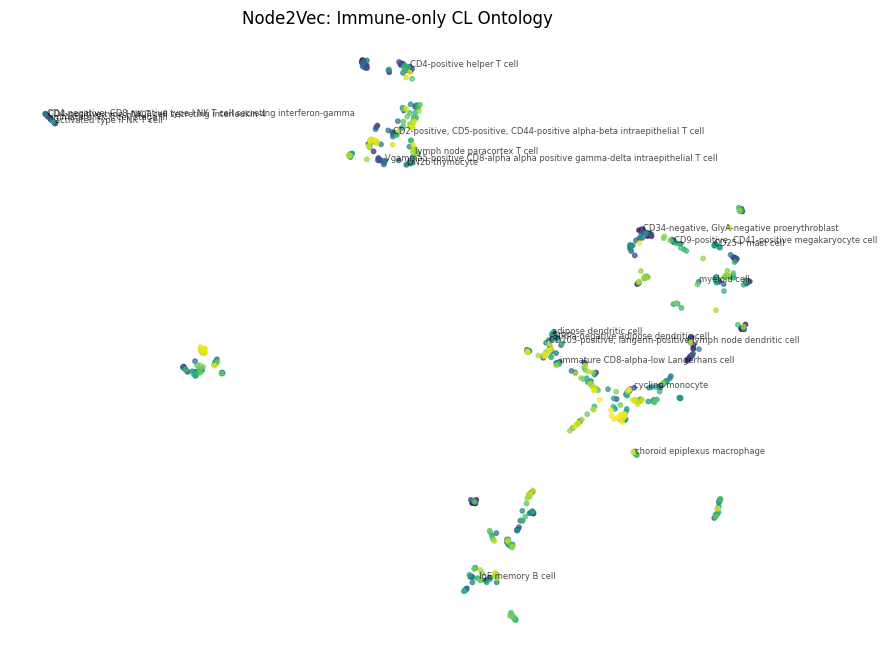

In [10]:
df_umap = visualize_n2v(n2v_immune, cl_graph, "Node2Vec: Immune-only CL Ontology")

In [8]:
# Extract ID → label mapping
id2name = {node: data.get("name", node) for node, data in immune_subgraph.nodes(data=True)}

In [12]:
import pandas as pd
import numpy as np

def export_top_neighbors(sim_matrix, cell_names, cl_graph, k=5, out_csv="neighbors.csv"):
    """
    Compute top-k cosine similarity neighbors for each ontology term
    and save results to a CSV file.

    Parameters
    ----------
    sim_matrix : np.ndarray
        Cosine similarity matrix (n x n).
    cell_names : list
        List of ontology term IDs (order matches sim_matrix).
    cl_graph : networkx.MultiDiGraph
        Graph from obonet containing 'name' attributes.
    k : int
        Number of neighbors to extract per node.
    out_csv : str
        Path to save CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame of neighbors with columns [ID, Name, Neighbor_ID, Neighbor_Name, Rank, Similarity].
    """

    # ID → name mapping
    id2name = {node: data.get("name", node) for node, data in cl_graph.nodes(data=True)}

    records = []
    for i, cell in enumerate(cell_names):
        topk_idx = np.argsort(-sim_matrix[i])[1:k+1]  # skip self
        for rank, j in enumerate(topk_idx, start=1):
            records.append({
                "ID": cell,
                "Name": id2name.get(cell, cell),
                "Neighbor_ID": cell_names[j],
                "Neighbor_Name": id2name.get(cell_names[j], cell_names[j]),
                "Rank": rank,
                "Similarity": sim_matrix[i, j]
            })

    df = pd.DataFrame(records)
    df.to_csv(out_csv, index=False)
    return df

In [9]:
immune_descendants =list(immune_subgraph.nodes())
print(", ".join([f"'{i}'" for i in immune_descendants]))
print(len(immune_descendants))

'CL:0011008', 'CL:0000932', 'CL:0000875', 'CL:0002044', 'CL:0002489', 'CL:0011024', 'CL:0002027', 'CL:0000517', 'CL:0000789', 'CL:0002015', 'CL:0000931', 'CL:0001010', 'CL:0002466', 'CL:0001005', 'CL:0002530', 'CL:0000965', 'CL:0009037', 'CL:4052053', 'CL:0002505', 'CL:0000041', 'CL:0002441', 'CL:0011023', 'CL:0002019', 'CL:0002434', 'CL:0001077', 'CL:0000816', 'CL:0000952', 'CL:0000945', 'CL:0000828', 'CL:0002513', 'CL:0002025', 'CL:0002050', 'CL:0000979', 'CL:0000942', 'CL:0002526', 'CL:0000974', 'CL:0000864', 'CL:0000790', 'CL:0000827', 'CL:0000873', 'CL:0009015', 'CL:0000953', 'CL:0000235', 'CL:0002431', 'CL:0000950', 'CL:4033043', 'CL:0000967', 'CL:0002119', 'CL:0000778', 'CL:0001201', 'CL:0002398', 'CL:0000870', 'CL:0000772', 'CL:0000838', 'CL:0009051', 'CL:0000990', 'CL:0000560', 'CL:0002028', 'CL:0009069', 'CL:0000233', 'CL:0002424', 'CL:0000970', 'CL:0000092', 'CL:0000973', 'CL:0000889', 'CL:0002087', 'CL:4033073', 'CL:0000901', 'CL:0009044', 'CL:0000987', 'CL:0000562', 'CL:00

In [23]:
import scanpy as sc

adata = sc.read(f"{DATA_PATH}/immune_1M_merged.h5ad")

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [25]:
# Build ID → name mapping from ontology graph
id2name = {node: data.get("name", node) for node, data in cl_graph.nodes(data=True)}

# Unique ontology IDs in AnnData
adata_ids = set(adata.obs["cell_type_ontology_term_id"].unique())

# Intersect with immune subtree IDs
immune_in_adata = adata_ids.intersection(immune_descendants)

print("Unique immune IDs in adata:", len(immune_in_adata))

# Print sorted list of IDs with names
for cid in sorted(list(immune_in_adata)):  # peek first 10
    print(cid, "->", id2name.get(cid, "N/A"))

Unique immune IDs in adata: 140
CL:0000037 -> hematopoietic stem cell
CL:0000038 -> erythroid progenitor cell
CL:0000049 -> common myeloid progenitor
CL:0000050 -> megakaryocyte-erythroid progenitor cell
CL:0000051 -> common lymphoid progenitor
CL:0000081 -> blood cell
CL:0000084 -> T cell
CL:0000094 -> granulocyte
CL:0000097 -> mast cell
CL:0000113 -> mononuclear phagocyte
CL:0000232 -> erythrocyte
CL:0000233 -> platelet
CL:0000235 -> macrophage
CL:0000236 -> B cell
CL:0000451 -> dendritic cell
CL:0000492 -> CD4-positive helper T cell
CL:0000542 -> lymphocyte
CL:0000545 -> T-helper 1 cell
CL:0000546 -> T-helper 2 cell
CL:0000549 -> basophilic erythroblast
CL:0000550 -> polychromatophilic erythroblast
CL:0000552 -> orthochromatic erythroblast
CL:0000553 -> megakaryocyte progenitor cell
CL:0000556 -> megakaryocyte
CL:0000557 -> granulocyte monocyte progenitor cell
CL:0000559 -> promonocyte
CL:0000576 -> monocyte
CL:0000583 -> alveolar macrophage
CL:0000623 -> natural killer cell
CL:0000

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


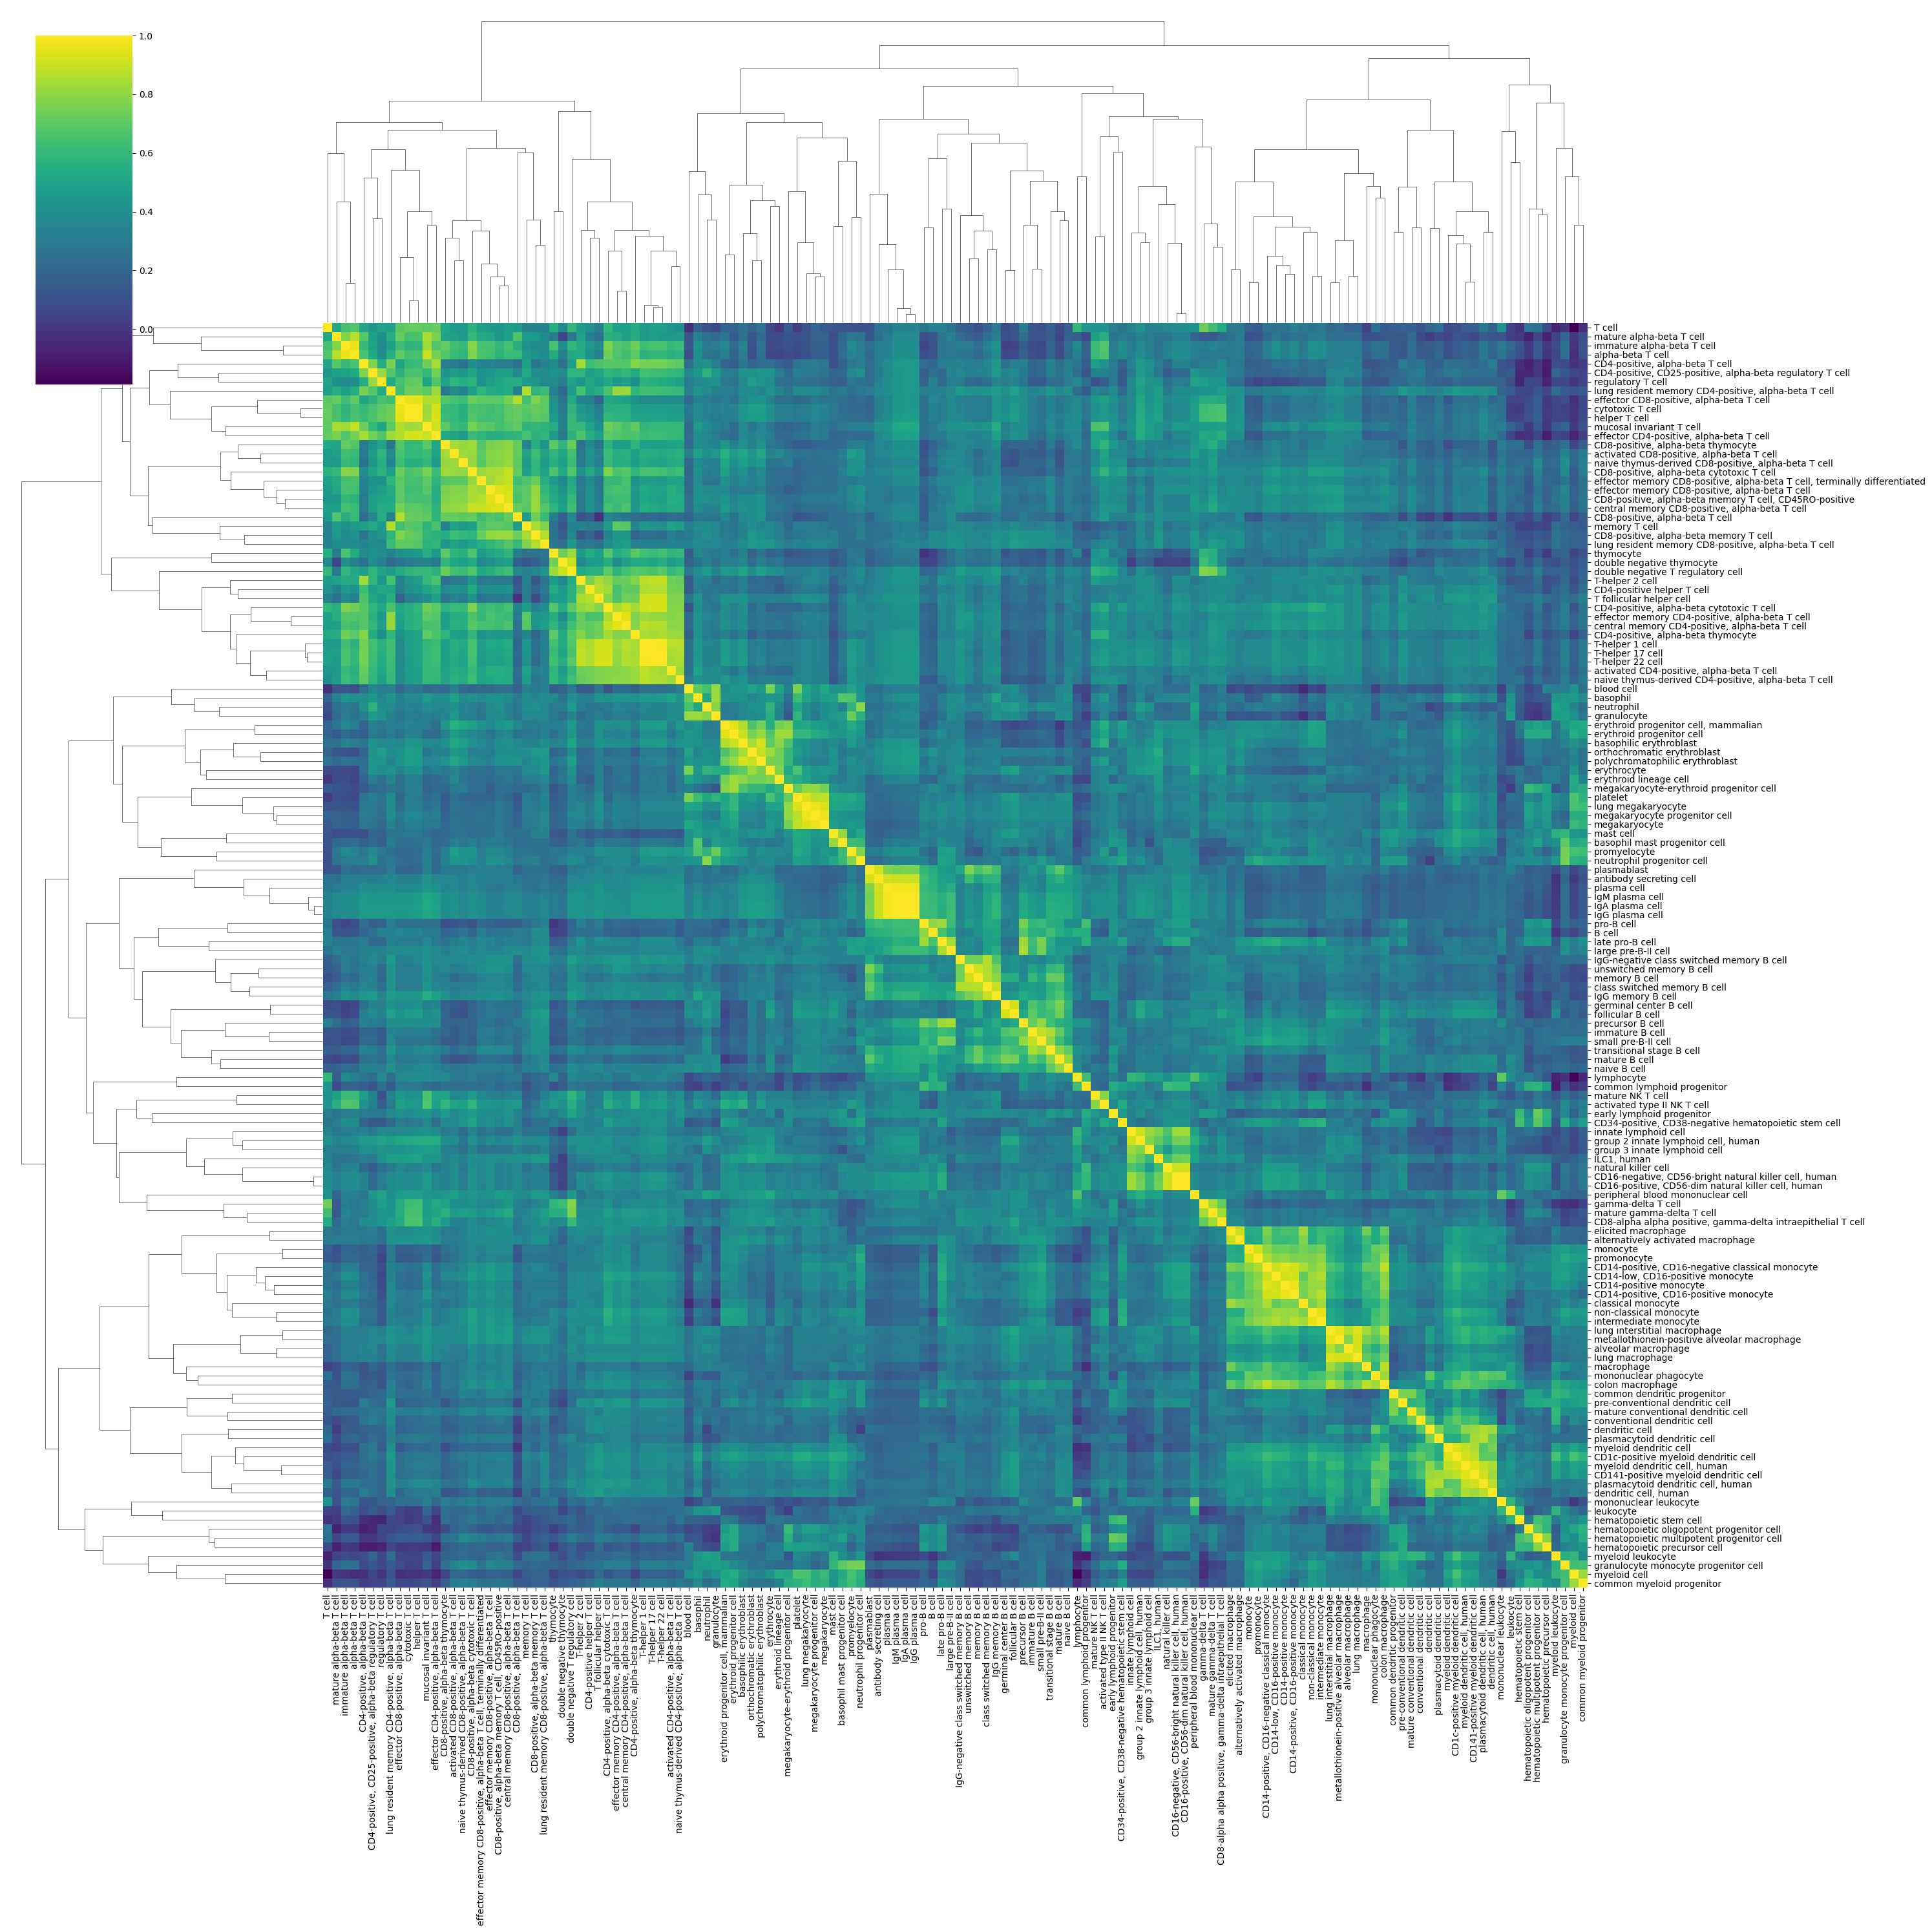

In [26]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Filter node IDs: only CL terms that are in immune_in_adata
cell_names = [c for c in n2v_immune.wv.index_to_key
              if c.startswith("CL:") and c in immune_in_adata]

# Build embeddings matrix
X = np.vstack([n2v_immune.wv[cell] for cell in cell_names])

# Compute cosine similarity
sim_matrix = cosine_similarity(X)

# Convert IDs → names for labels
labels = [id2name.get(cid, cid) for cid in cell_names]

# Clustered heatmap
g = sns.clustermap(sim_matrix, cmap="viridis",
               xticklabels=labels,
               yticklabels=labels,
               figsize=(30, 30))

plt.show()

g.savefig("immune_similarity_heatmap.png", dpi=300)   # 600 dpi = print quality

In [27]:
immune_filtered_adata = adata[adata.obs["cell_type_ontology_term_id"].isin(immune_descendants)].copy()

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [34]:
immune_filtered_adata.write_h5ad(f"{DATA_PATH}/immune_900K_filtered.h5ad")